In [1]:
import gwsurrogate

/home/omkarnm1401/miniconda3/envs/ut_codex/lib/python3.11/site-packages/gwtools/const.py:52: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


lal.MSUN_SI != Msun


In [2]:
from pathlib import Path
from io import StringIO
import pandas as pd

In [3]:
from gwtools.gwtools import minimize_norm_error_multi_mode

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import sys
# add the path to the script directory
sys.path.append("/home/omkarnm1401/UT_Austin/BHPTNRSurrogate/surrogates")
import BHPTNRSur1dq1e4 as bhptsur

/home/omkarnm1401/UT_Austin/BHPTNRSurrogate/surrogates/../data
**** Surrogate loaded: BHPTNRSur1dq1e4 ****


In [5]:
import matplotlib as mpl

sys.path.append("/home/omkarnm1401/UT_Austin/BHPTutils")
import bhpt_utils
mpl.rcdefaults()

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.sans-serif'] = ['Bitstream Vera Sans']
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.unicode_minus'] = False

plt.rcParams['text.usetex'] = False


In [6]:
nrsur = gwsurrogate.LoadSurrogate('NRHybSur3dq8')

Loaded NRHybSur3dq8 model


In [7]:
plot_dir = 'Notebook_plots/'

In [8]:
# convience wrapper for calling the NRHybSur3dq8 model
def generate_nrsur(q_input, f_low=None, t_start=None):
    chiA = [0, 0, 0.0]
    chiB = [0, 0, 0.0]
    dt = 0.1        # step size, Units of M
    if f_low==None:
        f_low=5e-3
    if t_start==None:
        t_start=-5000.1
    # dyn stands for dynamics and is always None for this model
    t, h, dyn = nrsur(q_input, chiA, chiB, dt=dt, f_low=f_low) 
    # we only take the last 5000M long waveform to calibrate
    indx = np.where(t>=t_start)
    t = t[indx]
    for mode in h.keys():
        h[mode] = h[mode][indx]
    return t,h

In [9]:
q_input = 10
mass_norm = 1/(1+1/q_input)

In [10]:
tnr, h_NRHybSur3dq8 = generate_nrsur(q_input=q_input)

In [11]:
nr_modes = list(h_NRHybSur3dq8.keys())
for mode in nr_modes:
    if mode[1] <=0: # m<=0; remove the (2,0) and (3,0) modes from NRHybSur3dq8 (these are not included in the BHPTNRSur1dq1e4 model)
        h_NRHybSur3dq8.pop(mode)
        
tbhpt, hbhpt = bhptsur.generate_surrogate(q=q_input, modes=h_NRHybSur3dq8.keys(), calibrated=False, neg_modes=False)

**** warning **** : modes are NOT NR calibrated - waveforms only have 0PA contribution


In [12]:
h_NR_22 = h_NRHybSur3dq8[(2, 2)]

In [13]:
import gwtools

In [14]:
def mathcalE_error(h1, h2):
    """
    Compute time-domain waveform error.

    Calculates the normalized L2 error between two waveforms using the metric
    defined in Eq. 21 of https://arxiv.org/pdf/1701.00550.pdf

    Parameters:
    -----------
    h1 : array (complex)
        Reference waveform (used for normalization)
    h2 : array (complex)
        Comparison waveform (same length as h1)

    Returns:
    --------
    normed_errs : float
        Normalized error: (||h1||² + ||h2||² - 2*Re(<h1,h2>)) / (2*||h1||²)
        Value of 0 indicates perfect agreement, larger values indicate greater disagreement

    Notes:
    ------
    - Assumes h1 is the reference waveform and normalizes by its magnitude
    - Both waveforms should have the same time sampling
    - The metric is symmetric in the numerator but asymmetric due to normalization by ||h1||²
    """
    # Compute norms squared
    n1Sqr = np.sum(np.abs(h1)**2)
    n2Sqr = np.sum(np.abs(h2)**2)

    # Compute inner product
    dots = np.array([h1[i] * (h2[i].conjugate()) for i in range(len(h1))])
    sdot = np.real(np.sum(dots))

    # Normalize error by reference waveform magnitude
    normed_errs = ((n1Sqr + n2Sqr) - 2 * sdot) / (2 * n1Sqr)

    return normed_errs

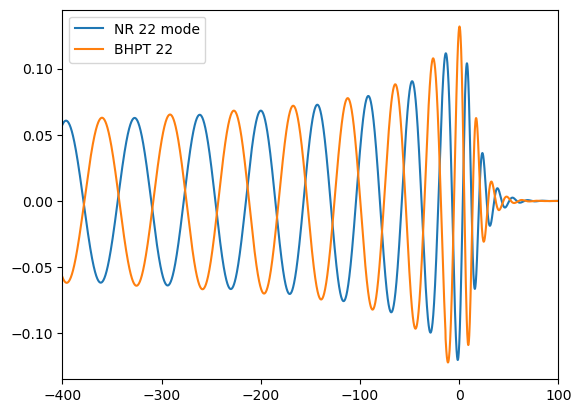

In [15]:
plt.plot(tnr, np.real(h_NR_22), label = 'NR 22 mode')
plt.plot(tbhpt  * mass_norm, np.real(hbhpt[(2,2)])  * mass_norm, label = 'BHPT 22')

plt.xlim(-400, 100)
plt.legend()

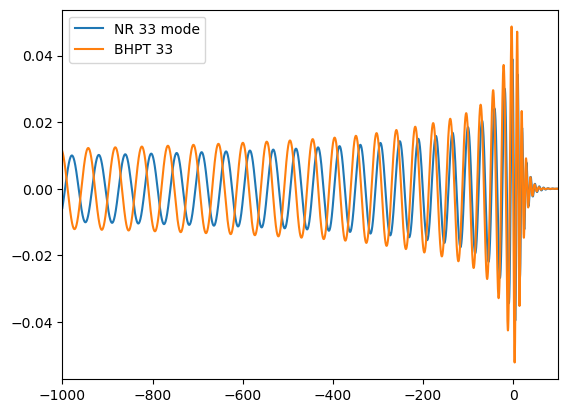

In [16]:
h_nr_33 = h_NRHybSur3dq8[(3, 3)]

plt.plot(tnr, np.real(h_nr_33), label = 'NR 33 mode')
plt.plot(tbhpt  * mass_norm, np.real(hbhpt[(3,3)])  * mass_norm, label = 'BHPT 33')

plt.xlim(-1000, 100)
plt.legend()

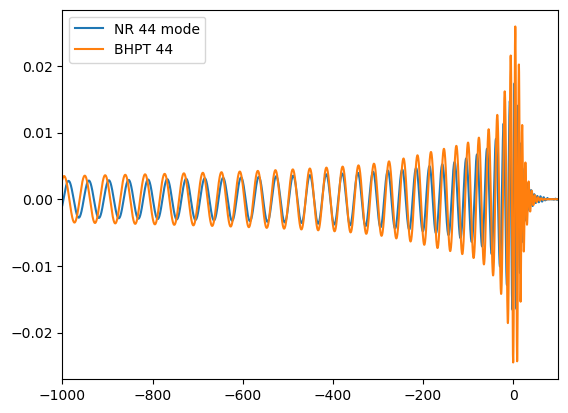

In [17]:
h_nr_44 = h_NRHybSur3dq8[(4, 4)]

plt.plot(tnr, np.real(h_nr_44), label = 'NR 44 mode')
plt.plot(tbhpt  * mass_norm, np.real(hbhpt[(4, 4)])  * mass_norm, label = 'BHPT 44')

plt.xlim(-1000, 100)
plt.legend()

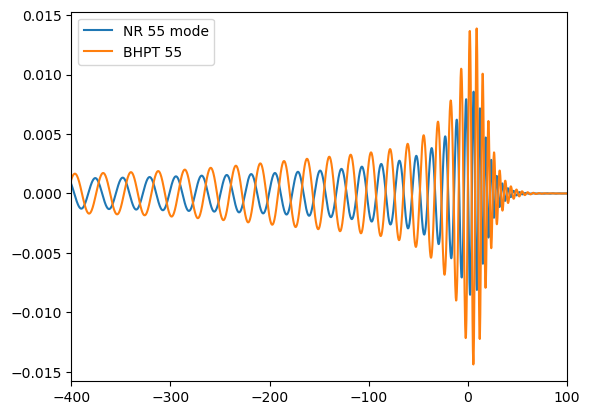

In [18]:
h_nr_55 = h_NRHybSur3dq8[(5, 5)]

plt.plot(tnr, np.real(h_nr_55), label = 'NR 55 mode')
plt.plot(tbhpt  * mass_norm, np.real(hbhpt[(5, 5)])  * mass_norm, label = 'BHPT 55')

plt.xlim(-400, 100)
plt.legend()

In [19]:
h_bhpt_interp = gwtools.interpolate_h(tbhpt * mass_norm, hbhpt[(2,2)], tnr)
mathcalE_error(h_NR_22, h_bhpt_interp)

>>> Warning: Requested samples are outside of interpolated domain.


np.float64(1.2687483420316126)

# %load scaling_qandtdep.md
# q- and time-dependent scaling fit

Fit form for the raw BHPT-to-NRHybSur3dq8 `(2,2)` comparison:

```python
x = 2 * (t - t_min) / (t_max - t_min) - 1
t_min = -6188.39999991155
t_max = 114.800000111376

alpha(q, t) = A_alpha(q) + B_alpha(q) * x
beta(q, t) = A_beta(q) + B_beta(q) * x
```

The time map is the integral of `beta(q,t)` over raw BHPT source time:

```python
u = t - t_min
tau(q, t) = tau0(q) + A_beta(q) * u + B_beta(q) * (u**2 / (t_max - t_min) - u)
h_model(tau(q,t)) = alpha(q,t) * exp(1j * phi0(q)) * h_BHPT(t)
```

The per-q fit used 40 uniformly spaced q values from 3 to 8. BHPT waveforms used `calibrated=False`; NR waveforms used `NRHybSur3dq8`, nonspinning, `dt=0.1`, `f_low=5e-3`, and `t_start=-5000.1`. The error is the `mathcalE_error` definition in `NRBHP_ansatz.py`, with NR as the reference waveform.

For the master q-fit, each coefficient is represented as a quartic polynomial in `1/q`:

```python
C(q) = c0 + c1/q + c2/q**2 + c3/q**3 + c4/q**4
```

## master coefficients

| coefficient | c0 | c1 | c2 | c3 | c4 |
|:---|---:|---:|---:|---:|---:|
| A_alpha | 0.976171791159 | -0.778956782043 | -1.28787253157 | 6.33386048743 | -7.91631393906 |
| B_alpha | 0.0702539047414 | -1.57701958245 | 11.5769375058 | -36.8706584362 | 43.019729202 |
| A_beta | 1.01000225746 | -1.4304387786 | 2.92452363501 | -5.74229616448 | 5.40048489432 |
| B_beta | 0.0204636411524 | -0.417970387782 | 2.82815635264 | -8.03147578502 | 8.38612749902 |

Equivalent Python definitions:

```python
A_alpha(q) = 0.976171791159 + (-0.778956782043) / q**1 + (-1.28787253157) / q**2 + (6.33386048743) / q**3 + (-7.91631393906) / q**4
B_alpha(q) = 0.0702539047414 + (-1.57701958245) / q**1 + (11.5769375058) / q**2 + (-36.8706584362) / q**3 + (43.019729202) / q**4
A_beta(q) = 1.01000225746 + (-1.4304387786) / q**1 + (2.92452363501) / q**2 + (-5.74229616448) / q**3 + (5.40048489432) / q**4
B_beta(q) = 0.0204636411524 + (-0.417970387782) / q**1 + (2.82815635264) / q**2 + (-8.03147578502) / q**3 + (8.38612749902) / q**4
```

## error summary

| model | min mathcalE | median mathcalE | max mathcalE | q at max |
|:---|---:|---:|---:|---:|
| independent per-q coefficients | 0.000360099 | 0.000828681 | 0.00185228 | 3 |
| master q-fit coefficients, optimized tau0/phi0 | 0.000369083 | 0.00083664 | 0.0018512 | 3 |

The master-fit error row uses only the q-dependent `A/B` coefficient formulae above, while re-optimizing the nuisance integration constant `tau0(q)` and phase rotation `phi0(q)` for each q. These nuisance quantities are not included in the master coefficient ansatz.

## per-q fitted coefficients

| q | A_alpha | B_alpha | A_beta | B_beta | per-q mathcalE | master mathcalE | tau0 master | phi0 master |
|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 3 | 0.7101040217 | -0.002332562922 | 0.7120679887 | 0.001341657741 | 0.00185228 | 0.0018512 | -4402.259442 | -0.006648356683 |
| 3.1282051 | 0.720047318 | -0.007943423576 | 0.7204305846 | 0.001112694257 | 0.00172211 | 0.00172546 | -4453.614627 | -2.068306057 |
| 3.2564103 | 0.7285674414 | -0.008037095084 | 0.7283148068 | 0.0009049604605 | 0.00162756 | 0.00163193 | -4502.430551 | 1.851605841 |
| 3.3846154 | 0.7367383142 | -0.007720053945 | 0.7357621159 | 0.000695712286 | 0.00154769 | 0.0015507 | -4548.773757 | -0.8027803461 |
| 3.5128205 | 0.7440822144 | -0.008192932118 | 0.7428167155 | 0.0005161008735 | 0.00147779 | 0.00147877 | -4592.750423 | 2.558354829 |
| 3.6410256 | 0.7511611162 | -0.008247516377 | 0.749516161 | 0.0003664962539 | 0.00141634 | 0.00141646 | -4634.473645 | -0.6192252046 |
| 3.7692308 | 0.7578404009 | -0.008307865228 | 0.7558401287 | 0.0001575712432 | 0.00135988 | 0.00136025 | -4674.04821 | 2.24124846 |
| 3.8974359 | 0.7641519617 | -0.008343977809 | 0.761886379 | 3.258710121e-05 | 0.00130717 | 0.00130929 | -4711.664226 | -1.404908838 |
| 4.025641 | 0.7701317759 | -0.008359179782 | 0.7676260411 | -0.0001126428883 | 0.00125701 | 0.00126039 | -4747.413018 | 1.02097262 |
| 4.1538462 | 0.7757954631 | -0.008379636719 | 0.7730992284 | -0.0002377095366 | 0.00120852 | 0.00121253 | -4781.438534 | -3.041760184 |
| 4.2820513 | 0.7811723654 | -0.008390065206 | 0.7783214909 | -0.0003492379346 | 0.00116175 | 0.00116557 | -4813.856106 | -1.007715303 |
| 4.4102564 | 0.7862840131 | -0.008392209396 | 0.7833108821 | -0.0004451579786 | 0.00111697 | 0.00111956 | -4844.79217 | 0.8456115874 |
| 4.5384615 | 0.791150255 | -0.008385305714 | 0.7880799613 | -0.0005325878622 | 0.00107406 | 0.00107558 | -4874.326674 | 2.526459906 |
| 4.6666667 | 0.7957875402 | -0.008375923935 | 0.7926377855 | -0.000622959765 | 0.00103331 | 0.00103386 | -4902.561043 | -2.233726184 |
| 4.7948718 | 0.8002114817 | -0.008365459609 | 0.7970016119 | -0.0007081171427 | 0.000994992 | 0.000995016 | -4929.578684 | -0.8647128276 |
| 4.9230769 | 0.8044356514 | -0.008353968073 | 0.8011948571 | -0.0007620036228 | 0.000958796 | 0.000959334 | -4955.477808 | 0.3554471309 |
| 5.0512821 | 0.808472277 | -0.008352305699 | 0.8052138764 | -0.0008171675616 | 0.000925124 | 0.000926922 | -4980.311765 | 1.439544367 |
| 5.1794872 | 0.8123402488 | -0.008334317135 | 0.8090696884 | -0.0008734628774 | 0.000894036 | 0.000897551 | -5004.149491 | 2.391459677 |
| 5.3076923 | 0.8160456342 | -0.008318863152 | 0.8127750213 | -0.0009231169938 | 0.00086564 | 0.000871277 | -5027.062604 | -3.0684903 |
| 5.4358974 | 0.8195980309 | -0.008286732649 | 0.8163326182 | -0.0009808092903 | 0.000840015 | 0.000847504 | -5049.100433 | -2.363707625 |
| 5.5641026 | 0.823018182 | -0.008299736867 | 0.8197523542 | -0.001042026277 | 0.000817347 | 0.000825776 | -5070.324033 | -1.775453431 |
| 5.6923077 | 0.82640433 | -0.008481560344 | 0.8230467652 | -0.001097708089 | 0.000797645 | 0.00080573 | -5090.780342 | -1.299132774 |
| 5.8205128 | 0.8294353226 | -0.008230329738 | 0.8262124283 | -0.001166935174 | 0.000780942 | 0.000787406 | -5110.513746 | -0.9271824221 |
| 5.9487179 | 0.8327946847 | -0.007758495289 | 0.8292625313 | -0.001218204959 | 0.000767903 | 0.000771115 | -5129.563889 | -0.6555065904 |
| 6.0769231 | 0.8357870949 | -0.009333507241 | 0.8322029113 | -0.001314864124 | 0.000756543 | 0.000757698 | -5147.974453 | -0.4835371745 |
| 6.2051282 | 0.8384521298 | -0.009058960106 | 0.8350457713 | -0.001372519111 | 0.000747404 | 0.000747409 | -5165.775551 | -0.4047528879 |
| 6.3333333 | 0.84121173 | -0.009197417298 | 0.8377808898 | -0.001458981446 | 0.000737422 | 0.000738561 | -5182.980157 | -0.4175416278 |
| 6.4615385 | 0.8435832457 | -0.008166771 | 0.8404294451 | -0.00154147108 | 0.000724995 | 0.00072946 | -5199.629903 | -0.5173098057 |
| 6.5897436 | 0.8461056007 | -0.008214861416 | 0.8430019091 | -0.001594849323 | 0.000708309 | 0.00071739 | -5215.742062 | -0.7013252179 |
| 6.7179487 | 0.8485832713 | -0.00812211869 | 0.8454972919 | -0.001637056449 | 0.000686319 | 0.000699413 | -5231.342002 | -0.966845917 |
| 6.8461538 | 0.8509558643 | -0.008090191902 | 0.8479267701 | -0.001650898704 | 0.000658039 | 0.000673121 | -5246.44405 | -1.311908894 |
| 6.974359 | 0.8532537255 | -0.008064823301 | 0.8502947344 | -0.001634702342 | 0.000623468 | 0.000637237 | -5261.070862 | -1.733568749 |
| 7.1025641 | 0.855477593 | -0.008032870815 | 0.8526044806 | -0.001588298319 | 0.000583239 | 0.00059261 | -5275.241131 | -2.228903809 |
| 7.2307692 | 0.8576306655 | -0.00800112924 | 0.8548499869 | -0.001535626199 | 0.000540454 | 0.000544692 | -5288.977773 | -2.795013203 |
| 7.3589744 | 0.8597145299 | -0.007972152848 | 0.857040572 | -0.001453719554 | 0.000498564 | 0.000499317 | -5302.303562 | 2.851641867 |
| 7.4871795 | 0.861731588 | -0.007949294865 | 0.8591706318 | -0.001363679471 | 0.000460144 | 0.000460258 | -5315.257082 | 2.147629674 |
| 7.6153846 | 0.8636843521 | -0.007937755726 | 0.8612364765 | -0.001280288588 | 0.000426653 | 0.000428723 | -5327.840073 | 1.380057649 |
| 7.7435897 | 0.8655782186 | -0.007920213401 | 0.8632400017 | -0.001203220404 | 0.00039887 | 0.000404327 | -5340.088102 | 0.5486701114 |
| 7.8717949 | 0.8674142987 | -0.00791191218 | 0.8651825643 | -0.001133446252 | 0.000376859 | 0.000385186 | -5352.019878 | -0.3416331959 |
| 8 | 0.8691930751 | -0.007899581066 | 0.8670636626 | -0.001076779176 | 0.000360099 | 0.000369083 | -5363.645208 | -1.29289967 |

No extrapolated BHPT samples are used in the error calculation; each row masks the NR waveform to the common support of the transformed BHPT time array before interpolation.


In [20]:
def read_markdown_table_after_heading(md_path, heading):
    text = Path(md_path).read_text()

    start = text.index(heading)
    section = text[start:]

    lines = section.splitlines()

    table_lines = []
    in_table = False

    for line in lines:
        stripped = line.strip()

        if stripped.startswith("|") and stripped.endswith("|"):
            table_lines.append(stripped)
            in_table = True
        elif in_table:
            break

    if not table_lines:
        raise ValueError(f"No markdown table found after heading: {heading}")

    # Remove Markdown separator row, e.g. |:---|---:|---:|
    table_lines = [
        line for line in table_lines
        if not all(
            cell.strip().replace(":", "").replace("-", "") == ""
            for cell in line.strip("|").split("|")
        )
    ]

    csv_text = "\n".join(
        ",".join(cell.strip() for cell in line.strip("|").split("|"))
        for line in table_lines
    )

    return pd.read_csv(StringIO(csv_text))

In [21]:
master_df = read_markdown_table_after_heading(
    "scaling_qandtdep.md",
    "## master coefficients"
)

master_coeffs = master_df.set_index("coefficient")

In [22]:
def eval_master_coefficient(q, name):
    c = master_coeffs.loc[name]

    return (
        c["c0"]
        + c["c1"] / q
        + c["c2"] / q**2
        + c["c3"] / q**3
        + c["c4"] / q**4
    )

In [23]:
def A_alpha(q):
    return eval_master_coefficient(q, "A_alpha")

def B_alpha(q):
    return eval_master_coefficient(q, "B_alpha")

def A_beta(q):
    return eval_master_coefficient(q, "A_beta")

def B_beta(q):
    return eval_master_coefficient(q, "B_beta")

In [24]:
# %load scaling.md
#Using the low-order time-dependent fit for `q=5`, `(2,2)`, I get:


t_min = -6188.39999991155
t_max = 114.800000111376
def x(t):
    return 2 * (t - t_min) / (t_max - t_min) - 1

#Amplitude scaling:


def alpha(q, t):
    return A_alpha(q) + B_alpha(q) * x(t)


#Time map:

#```python
def tau(q, t):
    u = (t - t_min)
    return A_beta(q) * u + B_beta(q) * (u**2 / (t_max - t_min) - u)
#```

#So the corresponding time-dependent beta is:

#```python
def beta(q, t):
    return A_beta(q) + B_beta(q) * x(t)
#```

#I also included a constant phase rotation:

#```python
#phi0 = 1.97530886542818  # radians
#```

#Applied as:

#```python
tbhpt_extcal = tau(q_input, tbhpt)

hbhpt_extcal = {
    (2, 2): alpha(q_input, tbhpt) * hbhpt[(2,2)]
}
#```

#With common-support interpolation, this gave:

# ```text
# mathcalE = 0.0223913001494002
# ```

# on NR support approximately `[-4998.76, 86.97]`, so it is comfortably below the updated `< 1` target.


In [25]:
[errors_before_min, errors_after_min], [tc, phic], [common_times,h_bhpt_aligned,h_nr_aligned] = \
                            minimize_norm_error_multi_mode(tau(q_input, tbhpt),  hbhpt_extcal, tnr, h_NRHybSur3dq8, mode_list=None, ell_m_match=(2,2),\
                                    t_low_adj=0,t_up_adj=0,method='nelder-mead')

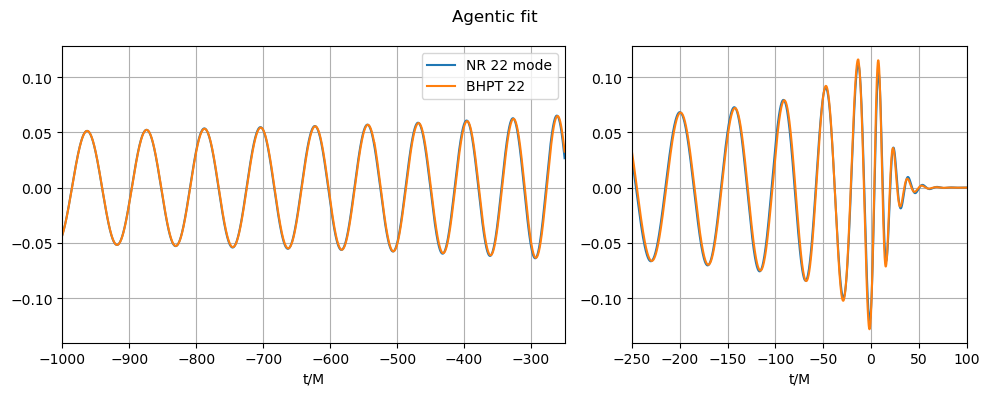

In [26]:
fig, (ax1, ax2) = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(10, 4), 
    gridspec_kw={'width_ratios': [3, 2]}
)



ax1.plot(common_times, np.real(h_nr_aligned[(2,2)]), label = 'NR 22 mode')
ax1.plot(common_times, np.real(h_bhpt_aligned[(2, 2)]), label = 'BHPT 22')

ax1.set_xlim(-1000, -250)
ax1.grid(True)
ax1.set_xlabel('t/M')
ax1.legend()

ax2.plot(common_times, np.real(h_nr_aligned[(2,2)]), label = 'NR 22 mode')
ax2.plot(common_times, np.real(h_bhpt_aligned[(2, 2)]), label = 'BHPT 22')
ax2.set_xlabel('t/M')

ax2.set_xlim(-250, 100)
ax2.grid(True)

plt.suptitle('Agentic fit')


plt.tight_layout()
#plt.savefig(plot_dir + f'q_and_t_dependent_agentic_fit_waveforms_q={q_input}.pdf')
plt.show()

In [27]:
modes = [(2,2)]
ab = bhpt_utils.all_alpha_beta_1D_scaling_params(q_input, modes)
print(ab)

{'beta': 0.8904497499536992, 'alpha_l2m2': 0.8888345985300663}


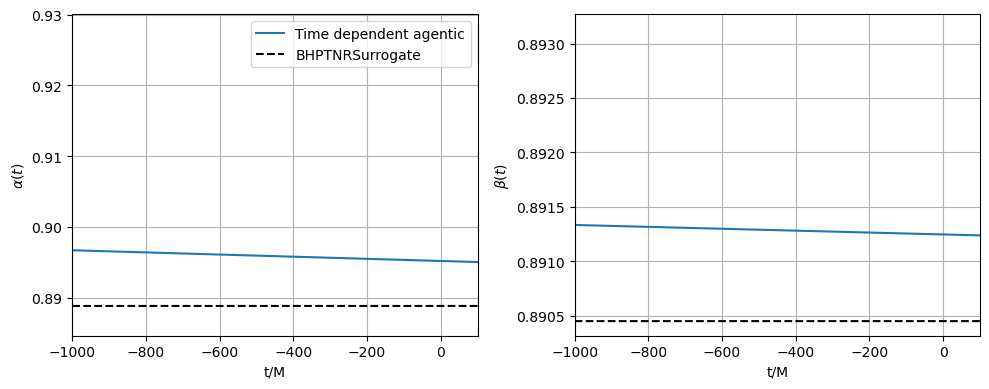

In [28]:
h_nr_22 = h_NRHybSur3dq8[(2, 2)]
fig, (ax1, ax2) = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(10, 4), 
    gridspec_kw={'width_ratios': [2, 2]}
)



#ax1.plot(tnr, np.real(h_nr_22), label = 'NR 22 mode')
ax1.plot(tbhpt_extcal, alpha(q_input, tbhpt), label = 'Time dependent agentic')
ax1.plot(tbhpt_extcal, np.ones(len(tbhpt_extcal)) * ab['alpha_l2m2'], label = 'BHPTNRSurrogate', linestyle = 'dashed', color = 'k')

ax1.set_xlim(-1000, 100)
ax1.grid(True)
ax1.set_xlabel('t/M')
ax1.set_ylabel(r'$\alpha(t)$')
ax1.legend()

#ax2.plot(tnr, np.real(h_nr_22), label = 'NR 22 mode')
ax2.plot(tbhpt_extcal, beta(q_input, tbhpt))
ax2.plot(tbhpt_extcal, np.ones(len(tbhpt_extcal)) * ab['beta'], linestyle = 'dashed', color = 'k')
ax2.set_xlabel('t/M')
ax2.set_ylabel(r'$\beta(t)$')

ax2.set_xlim(-1000, 100)
ax2.grid(True)

#plt.suptitle('Agentic fit')


plt.tight_layout()
#plt.savefig(plot_dir + f'q_and_t_dependent_agentic_fit_params_q={q_input}.pdf')
plt.show()

In [29]:
beta(q_input, tbhpt)

array([0.89313367, 0.89313366, 0.89313364, ..., 0.8907567 , 0.89075669,
       0.89075667], shape=(153075,))

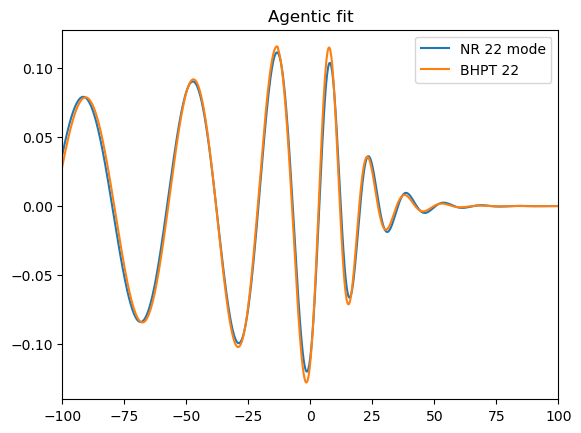

In [30]:
h_nr_22 = h_NRHybSur3dq8[(2, 2)]

plt.plot(common_times, np.real(h_nr_aligned[(2,2)]), label = 'NR 22 mode')
plt.plot(common_times, np.real(h_bhpt_aligned[(2, 2)]), label = 'BHPT 22')

plt.xlim(-100, 100)
plt.title('Agentic fit')

plt.legend()
plt.show()